# Kapitel 1 – Iris-Daten kennenlernen

In diesem Notebook lernen wir den klassischen **Iris-Datensatz** kennen.  
Wir verwenden dabei **nur einen einheitlichen Zugang** über `load_iris()` aus scikit-learn.

## Lernziele
Nach diesem Notebook können Sie:
- den Iris-Datensatz laden,
- `X`, `y`, `feature_names` und `target_names` einordnen,
- einen DataFrame aus den Iris-Daten erzeugen,
- erste Muster in den Daten visuell untersuchen.


**Dozentenversion mit Musterlösung**

Diese Fassung ergänzt kurze Musterantworten zu den Verständnisfragen am Ende des Notebooks.

## Abschnitt 1 – Bibliotheken importieren und Datensatz laden


In [1]:
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
iris = load_iris()

print("Verfügbare Attribute:")
print(iris.keys())


Verfügbare Attribute:
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


## Abschnitt 2 – Was steckt im Iris-Datensatz?

Der Datensatz enthält:
- **150 Samples** (Beobachtungen),
- **4 numerische Features**,
- **3 Klassen** von Iris-Blumen.


In [3]:
print("Feature-Namen:")
print(iris.feature_names)
print()
print("Klassen-Namen:")
print(iris.target_names)
print()
print("Form von iris.data:", iris.data.shape)
print("Form von iris.target:", iris.target.shape)


Feature-Namen:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Klassen-Namen:
['setosa' 'versicolor' 'virginica']

Form von iris.data: (150, 4)
Form von iris.target: (150,)


In [4]:
X = iris.data
y = iris.target

print("Erstes Sample in X:")
print(X[0])
print()
print("Erstes Label in y:")
print(y[0], "->", iris.target_names[y[0]])


Erstes Sample in X:
[5.1 3.5 1.4 0.2]

Erstes Label in y:
0 -> setosa


## Erläuterung der letzten Zeile im Detail

```python
print(y[0], "->", iris.target_names[y[0]])
```

**Schritt für Schritt:**

| Teil | Was es ist | Beispielwert |
|---|---|---|
| `y[0]` | Die numerische Klasse des ersten Samples | `0` |
| `"->"` | Ein Trennzeichen (einfacher Text) | `->` |
| `iris.target_names[y[0]]` | Der Name der Klasse | `'setosa'` |

**Der entscheidende Teil:** `iris.target_names[y[0]]`

Das ist eine **doppelte Indizierung**:
1. `y[0]` liefert die Zahl `0`
2. Diese Zahl wird dann als Index in `iris.target_names` verwendet → `iris.target_names[0]`
3. `iris.target_names` ist ein Array: `['setosa', 'versicolor', 'virginica']`
4. Also: `iris.target_names[0]` → `'setosa'`

**Die komplette Ausgabe der letzten Zeile sieht so aus:**
```
0 -> setosa
```

Kurz gesagt: `y` speichert nur Zahlen (`0`, `1`, `2`), und mit `iris.target_names[y[0]]` übersetzt man diese Zahl in den lesbaren Blumennamen.

## Abschnitt 3 – Iris-Daten als DataFrame

Für die Arbeit mit Tabellen und Visualisierungen ist ein DataFrame oft besonders praktisch.


In [5]:
# Erstellt einen DataFrame aus den Daten (X) und verwendet die Feature-Namen als Spaltenbezeichnungen.
df = pd.DataFrame(X, columns=iris.feature_names)

# Fügt eine neue Spalte 'species_id' hinzu, die die numerischen Klassen-Labels (y) enthält.
df["species_id"] = y

# Fügt eine weitere Spalte 'species' hinzu, die die lesbaren Namen der Iris-Arten enthält, indem die numerischen IDs in Text übersetzt werden.
df["species"] = [iris.target_names[i] for i in y]

# Zeigt die ersten 5 Zeilen des erstellten DataFrames an.
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [6]:
print("Form des DataFrames:", df.shape)
print()
print("Klassenverteilung:")
print(df["species"].value_counts())


Form des DataFrames: (150, 6)

Klassenverteilung:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Abschnitt 4 – Erste statistische Übersicht


In [7]:
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## Abschnitt 5 – Erste Visualisierung

Wir betrachten zunächst zwei Merkmale:
- Sepal Length
- Sepal Width

Gleiche Farben bedeuten gleiche Klassen.


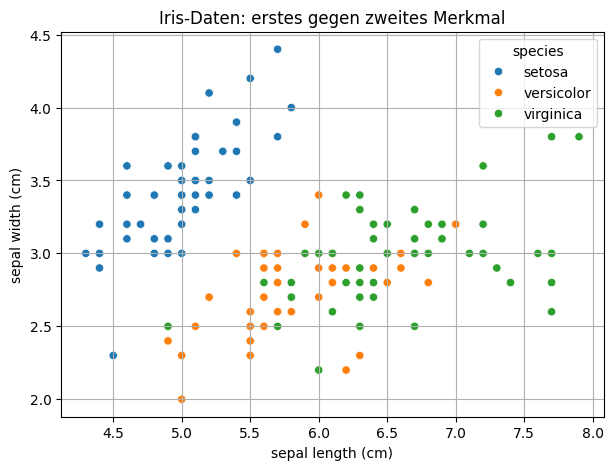

In [8]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x=iris.feature_names[0],
    y=iris.feature_names[1],
    hue="species"  # hue sagt seaborn: „Färbe die Punkte je nach dem Wert in dieser Spalte ein."
)
plt.title("Iris-Daten: erstes gegen zweites Merkmal")
plt.grid(True)
plt.show()


## Abschnitt 6 – Pairplot

Ein Pairplot zeigt paarweise Beziehungen zwischen mehreren Merkmalen.  
Damit können wir erkennen, welche Merkmale Klassen gut trennen.


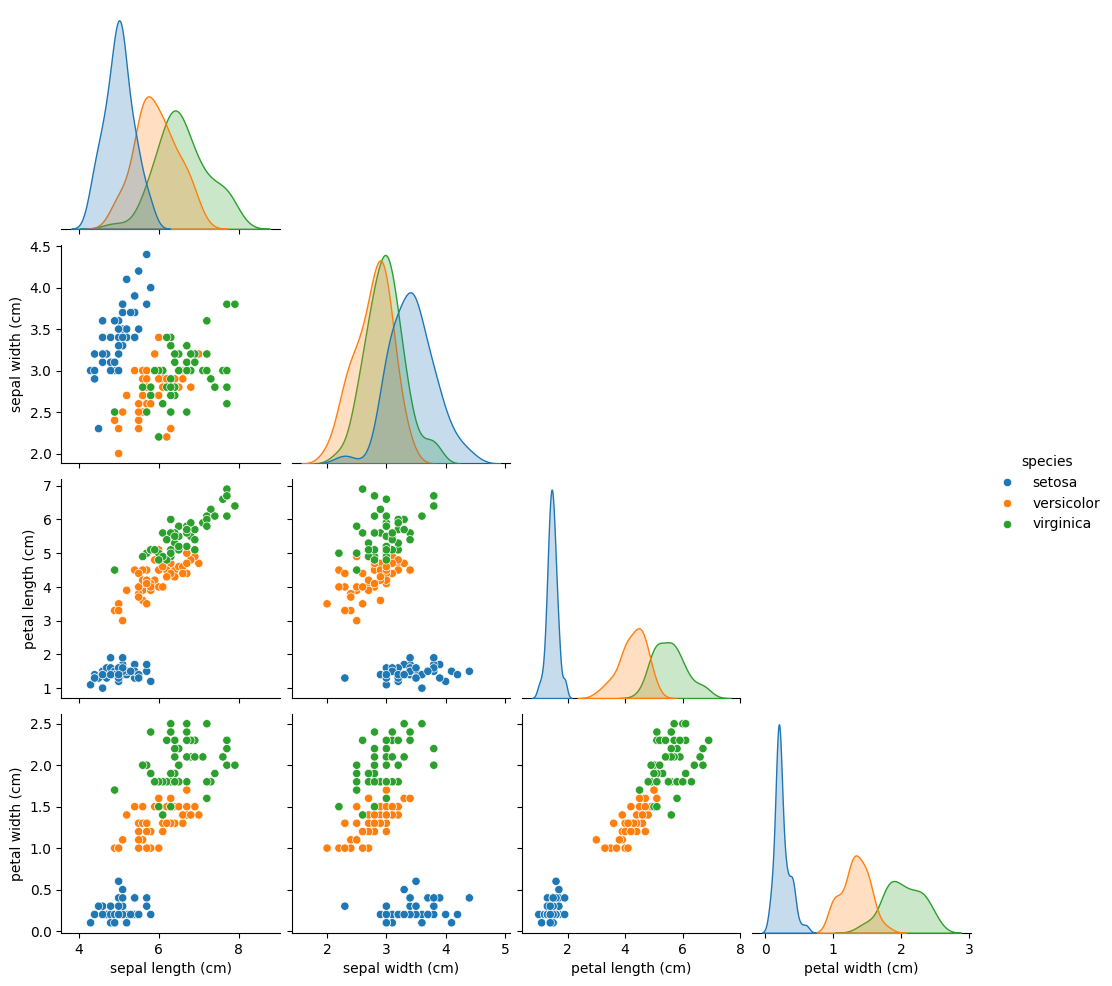

In [9]:
# Pairplot: Jede Merkmalskombination als Scatterplot, Diagonale = Verteilung pro Klasse
# Erkenntnis 1: Setosa (blau) ist in allen Plots klar von den anderen getrennt
# Erkenntnis 2: Versicolor & Virginica überlappen bei sepal-Merkmalen stark
# Erkenntnis 3: petal length & petal width trennen die Klassen am besten
#               → diese Merkmale sind für ein ML-Modell besonders wertvoll
sns.pairplot(
    df,
    vars=iris.feature_names,
    hue="species",
    corner=True
)
plt.show()


## Pairplot – Alle Merkmale auf einen Blick

Ein Pairplot zeigt **jede Merkmalskombination** als Scatterplot.
Die **Diagonale** zeigt statt eines Scatterplots die **Verteilung**
(KDE-Kurve) jedes einzelnen Merkmals pro Klasse.

KDE steht für Kernel Density Estimation – auf Deutsch: Kerndichteschätzung. Eine KDE-Kurve ist eine geglättete Version eines Histogramms. Sie zeigt, wo Werte häufig oder selten vorkommen.

### Was erkenne ich hier?

**🔵 Setosa ist immer klar getrennt**
→ In allen Plots liegt Setosa (blau) abseits der anderen beiden Klassen.
→ Setosa ist also anhand *jedes* Merkmals gut erkennbar.

**🟠🟢 Versicolor und Virginica überlappen sich**
→ Besonders bei `sepal length` und `sepal width` (oben links)
  liegen orange und grün durcheinander – schwer trennbar!
→ Bei `petal length` und `petal width` (unten rechts)
  sind sie deutlich besser getrennt.

**📌 Wichtigste Erkenntnis für ML:**
Die Merkmale `petal length` und `petal width` sind am
informativsten ("diskriminativ") – ein Modell sollte
sich besonders auf diese stützen.

**Diagonale (KDE-Kurven):**
→ Schmale, spitze Kurve = Werte liegen eng beieinander (z.B. Setosa bei petal width)
→ Breite, flache Kurve = Werte streuen stark

## Abschnitt 7 – Übungsaufgabe: Boxplot

Erstellen Sie einen **Boxplot**, der die Verteilung von `petal length (cm)` für jede der drei Iris-Arten darstellt.  
Verwenden Sie `sns.boxplot()` mit `x="species"` und `y="petal length (cm)"`.

**Ziel:** Erkennen Sie, welche Art sich am deutlichsten von den anderen unterscheidet?


## Was ist ein Boxplot?

Ein Boxplot fasst die **Verteilung von Zahlenwerten** in einer kompakten
Grafik zusammen.


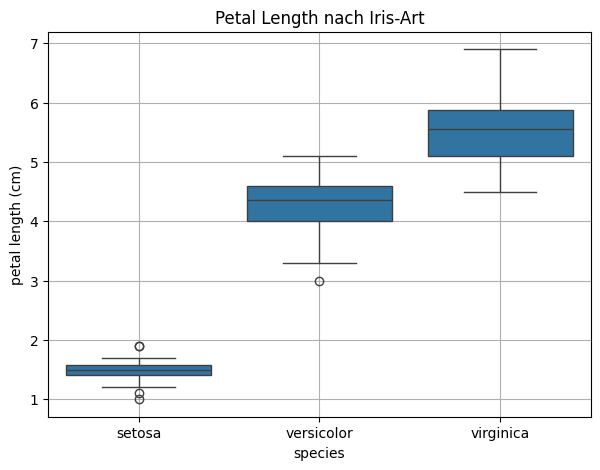

In [10]:
# Musterlösung
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x="species",
    y="petal length (cm)"
)
plt.title("Petal Length nach Iris-Art")
plt.grid(True)
plt.show()

# Beobachtung: Iris setosa hat klar kleinere Petal Length und ist gut von
# den anderen Arten trennbar. Versicolor und Virginica überlappen leicht.


## Verständnisfragen und Musterlösungen

1. **Unterschied zwischen `X` und `y`:**  
   `X` enthält die Eingabedaten bzw. Merkmale der Samples. `y` enthält die Zielvariable, also die Klassenlabels.

2. **Bedeutung von `feature_names` und `target_names`:**  
   `feature_names` sind die Namen der Merkmale, z. B. Kelchblatt- und Blütenblattmaße. `target_names` sind die Namen der Klassen, also die drei Iris-Arten.

3. **Wie viele Samples und Features?**  
   Der Datensatz enthält **150 Samples** und **4 Features**.

4. **Warum sind Visualisierungen hilfreich?**  
   Visualisierungen machen Zusammenhänge, Streuungen, mögliche Cluster und Trennbarkeit zwischen Klassen schneller sichtbar als reine Tabellen.
